# 04 — RFM Segmentation

## What is RFM?
RFM is a proven customer segmentation framework used across retail,
e-commerce, and banking worldwide.

- **Recency** — days since last purchase (lower = better)
- **Frequency** — number of unique orders
- **Monetary** — total revenue generated

## Methodology
1. Calculate raw R, F, M values per customer
2. Score each dimension 1–5 using quintiles
3. Assign segments based on score combinations
4. Validate the 80/20 revenue concentration hypothesis

## Segments defined
| Segment | Description | Strategy |
|---|---|---|
| Champions | Bought recently, buy often, spend most | Reward them |
| Loyal Customers | Buy regularly, good spenders | Upsell |
| New Customers | Bought recently, not yet frequent | Onboard well |
| Potential Loyalists | Recent, some frequency | Build habit |
| Need Attention | Average scores across all three | Re-engage |
| At Risk | Good history but not buying lately | Win back |
| Cannot Lose Them | High value but going dormant | Act fast |
| Hibernating | Low scores, long inactive | Low-cost campaigns |
| Lost | Lowest scores | Minimal investment |

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'font.size'         : 11,
})

df = pd.read_csv('../data/online_retail_clean.csv', parse_dates=['invoicedate'])

print(f"Data loaded: {len(df):,} rows ✓")

Data loaded: 802,932 rows ✓


Set the reference date

In [27]:
# Reference date = 1 day after the last transaction
# This is the "today" from which we measure recency
reference_date = df['invoicedate'].max() + pd.Timedelta(days=1)

print(f"Reference date: {reference_date.date()}")

Reference date: 2011-12-10


Calculate raw RFM values

In [28]:
rfm = df.groupby('customer_id').agg(
    recency   = ('invoicedate', lambda x: (reference_date - x.max()).days),
    frequency = ('invoice',     'nunique'),
    monetary  = ('revenue',     'sum')
).reset_index()

rfm['monetary'] = rfm['monetary'].round(2)

print(f"RFM table built for {len(rfm):,} customers")
print(f"\n=== RFM Summary Statistics ===")
print(rfm[['recency','frequency','monetary']].describe().round(2))

RFM table built for 5,862 customers

=== RFM Summary Statistics ===
       recency  frequency   monetary
count  5862.00    5862.00    5862.00
mean    200.99       6.25    2977.10
std     209.22      12.79   14627.03
min       1.00       1.00       2.95
25%      26.00       1.00     344.64
50%      96.00       3.00     880.63
75%     379.00       7.00    2286.34
max     739.00     378.00  608821.65


Assign RFM scores (1–5 scale)   Higher is always better:



Recency: lower days = higher score

Frequency: more orders = higher score

Monetary: more spend = higher score

In [29]:
rfm['r_score'] = pd.qcut(rfm['recency'],
                          q=5,
                          labels=[5, 4, 3, 2, 1])  # reversed — less days = better

rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                          q=5,
                          labels=[1, 2, 3, 4, 5])

rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'),
                          q=5,
                          labels=[1, 2, 3, 4, 5])

# Convert to int
rfm[['r_score','f_score','m_score']] = rfm[['r_score','f_score','m_score']].astype(int)

# Combined RFM score string (useful for segment mapping)
rfm['rfm_score'] = (rfm['r_score'].astype(str)
                    + rfm['f_score'].astype(str)
                    + rfm['m_score'].astype(str))

# Single composite score (weighted: recency matters most)
rfm['rfm_combined'] = (rfm['r_score'] * 0.4
                       + rfm['f_score'] * 0.3
                       + rfm['m_score'] * 0.3).round(2)

print("RFM scores assigned ✓")
rfm.head(10)

RFM scores assigned ✓


,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_combined
0,12346,326,12,77556.46,2,5,5,255,3.8
1,12347,2,8,5633.32,5,4,5,545,4.7
2,12348,75,5,1658.40,3,4,4,344,3.6
3,12349,19,3,3678.69,5,3,5,535,4.4
4,12350,310,1,294.40,2,1,2,212,1.7
5,12351,375,1,300.93,2,1,2,212,1.7
6,12352,36,9,1729.54,4,5,4,454,4.3
7,12353,204,2,406.76,2,2,2,222,2.0
8,12354,232,1,1079.40,2,1,3,213,2.0
9,12355,214,2,947.61,2,2,3,223,2.3


Assign customer segments

In [30]:
def assign_segment(row):
    r = row['r_score']
    f = row['f_score']
    m = row['m_score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2 and m <= 3:
        return 'Potential Loyalists'
    elif r == 3 and f <= 2:
        return 'Need Attention'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cannot Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Hibernating'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

print("=== Customer Segment Distribution ===")
segment_summary = (rfm.groupby('segment')
                      .agg(
                          customers  = ('customer_id', 'count'),
                          avg_recency   = ('recency',   'mean'),
                          avg_frequency = ('frequency', 'mean'),
                          avg_monetary  = ('monetary',  'mean'),
                          total_revenue = ('monetary',  'sum')
                      )
                      .round(2)
                      .sort_values('total_revenue', ascending=False)
                      .reset_index())

segment_summary['pct_customers'] = (segment_summary['customers']
                                    / segment_summary['customers'].sum() * 100).round(1)
segment_summary['pct_revenue'] = (segment_summary['total_revenue']
                                  / segment_summary['total_revenue'].sum() * 100).round(1)

display(segment_summary)

=== Customer Segment Distribution ===


,segment,customers,avg_recency,avg_frequency,avg_monetary,total_revenue,pct_customers,pct_revenue
0,Champions,1297,19.97,16.97,9204.22,11937870.79,22.1,68.4
1,Loyal Customers,1123,73.31,5.87,2239.42,2514863.70,19.2,14.4
2,At Risk,616,360.10,5.67,2513.83,1548519.12,10.5,8.9
3,New Customers,451,28.13,1.46,929.12,419033.51,7.7,2.4
4,Hibernating,457,405.41,2.20,866.67,396069.26,7.8,2.3
5,Lost,1269,466.95,1.18,254.09,322438.93,21.6,1.8
6,Potential Loyalists,436,81.07,2.64,431.57,188163.64,7.4,1.1
7,Need Attention,213,104.68,1.09,585.90,124797.35,3.6,0.7


Chart 1: Segment size vs revenue bubble chart

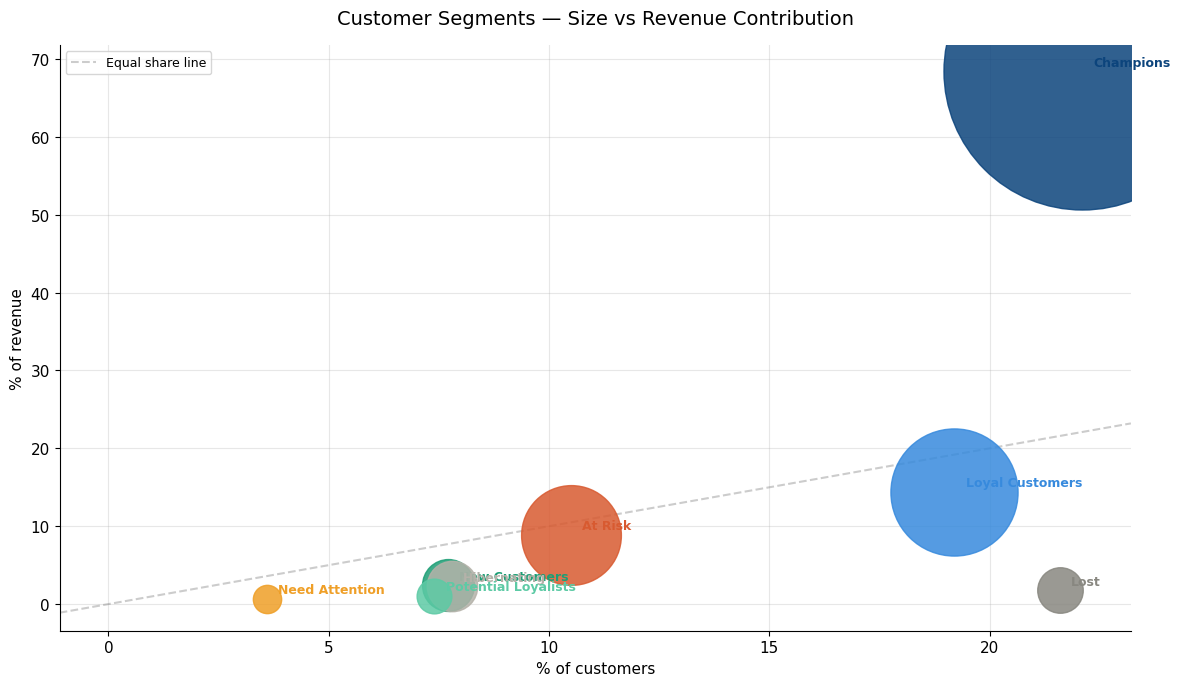

Chart 1 saved ✓


In [31]:
colors_map = {
    'Champions'          : '#0C447C',
    'Loyal Customers'    : '#378ADD',
    'New Customers'      : '#1D9E75',
    'Potential Loyalists': '#5DCAA5',
    'Need Attention'     : '#EF9F27',
    'At Risk'            : '#D85A30',
    'Cannot Lose Them'   : '#993C1D',
    'Lost'               : '#888780',
    'Hibernating'        : '#B4B2A9',
}

fig, ax = plt.subplots(figsize=(12, 7))

for _, row in segment_summary.iterrows():
    color = colors_map.get(row['segment'], '#888780')
    ax.scatter(row['pct_customers'], row['pct_revenue'],
               s=row['total_revenue'] / 300,
               color=color, alpha=0.85, zorder=3)
    ax.annotate(row['segment'],
                xy=(row['pct_customers'], row['pct_revenue']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=9, color=color, fontweight='bold')

ax.axline((0,0), slope=1, color='gray', linestyle='--',
          alpha=0.4, label='Equal share line')
ax.set_xlabel('% of customers', fontsize=11)
ax.set_ylabel('% of revenue', fontsize=11)
ax.set_title('Customer Segments — Size vs Revenue Contribution',
             fontsize=14, pad=15)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/figures/rfm_segment_bubble.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved ✓")

Chart 2: RFM segment treemap

In [32]:
fig = px.treemap(segment_summary,
                 path=['segment'],
                 values='customers',
                 color='pct_revenue',
                 color_continuous_scale='Blues',
                 custom_data=['pct_revenue', 'avg_monetary', 'avg_frequency'],
                 title='RFM Segments — Customer Count & Revenue Share')

fig.update_traces(
    texttemplate=(
        '<b>%{label}</b><br>'
        '%{value} customers<br>'
        '%{customdata[0]:.1f}% of revenue'
    ),
    hovertemplate=(
        '<b>%{label}</b><br>'
        'Customers: %{value}<br>'
        'Revenue share: %{customdata[0]:.1f}%<br>'
        'Avg spend: £%{customdata[1]:,.0f}<br>'
        'Avg frequency: %{customdata[2]:.1f} orders'
        '<extra></extra>'
    ),
    textfont_size=12
)
fig.update_layout(height=500, margin=dict(t=50, l=10, r=10, b=10))
fig.write_html('../outputs/figures/rfm_treemap.html')
fig.show()
print("Chart 2 saved ✓")

Chart 2 saved ✓


Chart 3: RFM score heatmap (F vs R, colored by monetary)

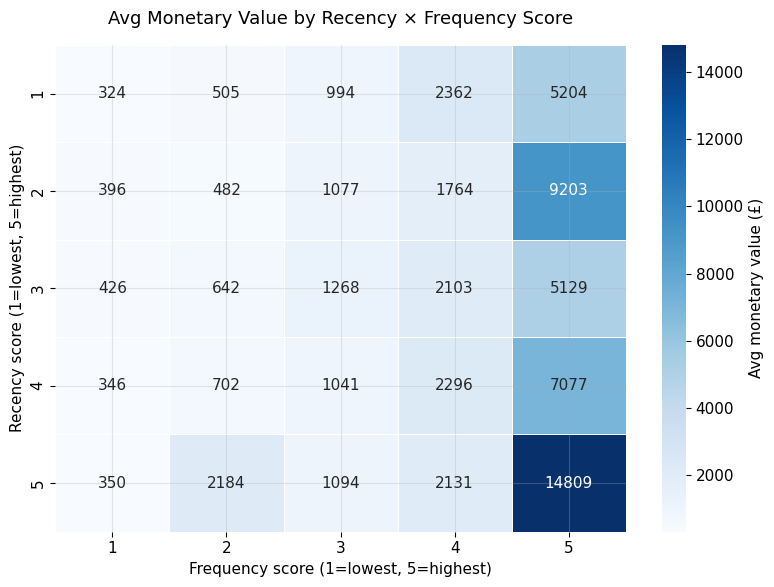

Chart 3 saved ✓


In [33]:
rfm_heat = rfm.groupby(['r_score','f_score'])['monetary'].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(rfm_heat,
            annot=True,
            fmt='.0f',
            cmap='Blues',
            ax=ax,
            linewidths=0.4,
            cbar_kws={'label': 'Avg monetary value (£)'})

ax.set_title('Avg Monetary Value by Recency × Frequency Score',
             fontsize=13, pad=15)
ax.set_xlabel('Frequency score (1=lowest, 5=highest)')
ax.set_ylabel('Recency score (1=lowest, 5=highest)')
plt.tight_layout()
plt.savefig('../outputs/figures/rfm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved ✓")

 Chart 4: Revenue distribution by segment

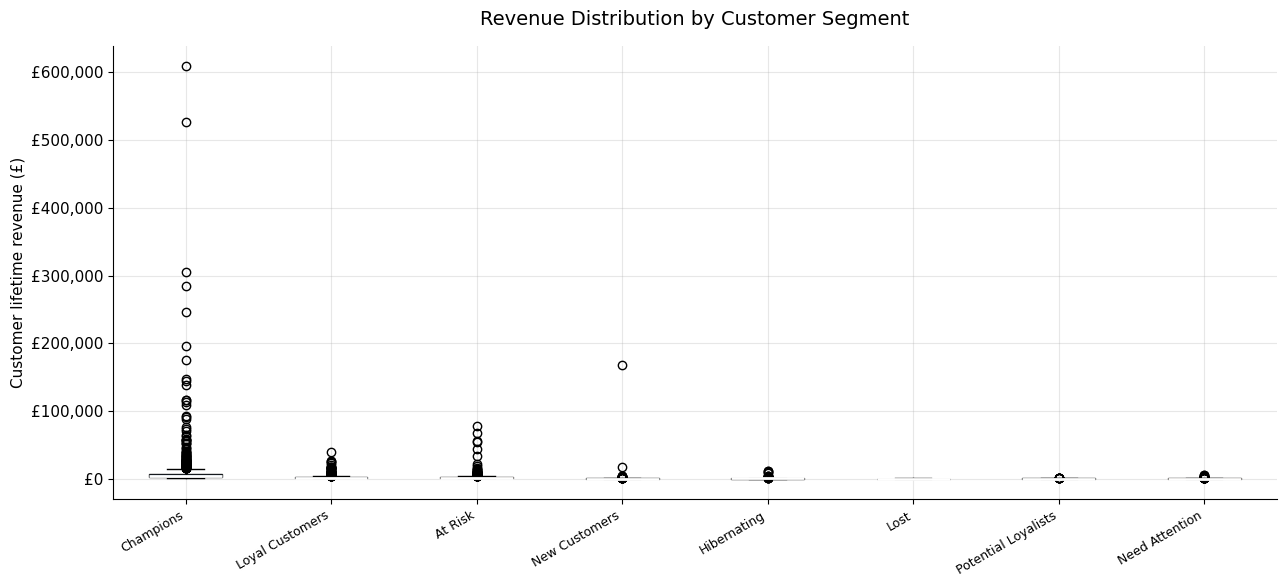

Chart 4 saved ✓


In [34]:
segment_order = (segment_summary.sort_values('total_revenue', ascending=False)
                                 ['segment'].tolist())

fig, ax = plt.subplots(figsize=(13, 6))

data_by_segment = [rfm[rfm['segment'] == s]['monetary'].values
                   for s in segment_order]

bp = ax.boxplot(data_by_segment,
                patch_artist=True,
                vert=True,
                medianprops=dict(color='white', linewidth=2))

for patch, segment in zip(bp['boxes'], segment_order):
    patch.set_facecolor(colors_map.get(segment, '#888780'))
    patch.set_alpha(0.85)

ax.set_xticks(range(1, len(segment_order) + 1))
ax.set_xticklabels(segment_order, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Customer lifetime revenue (£)')
ax.set_title('Revenue Distribution by Customer Segment', fontsize=14, pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('../outputs/figures/rfm_revenue_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved ✓")

Validate the 80/20 hypothesis

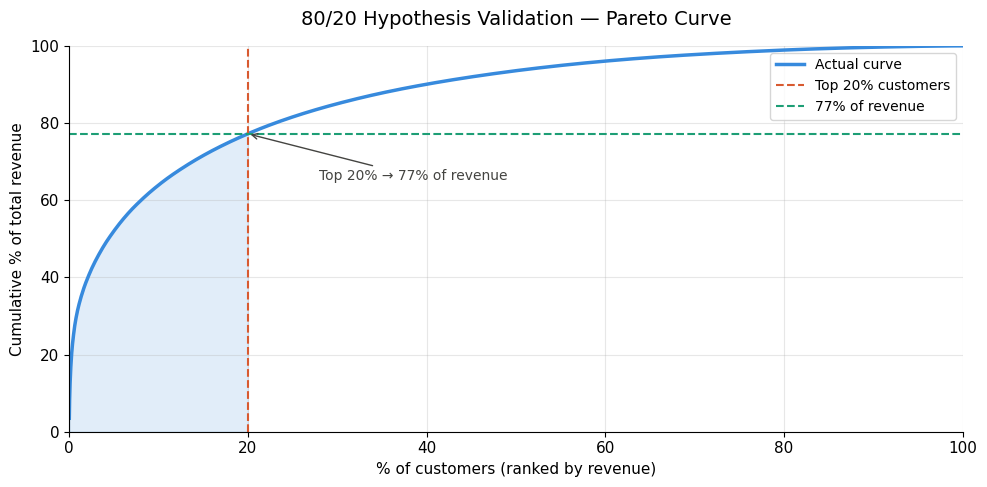


=== HYPOTHESIS VALIDATION ===
Top 20% of customers generate 77.2% of revenue
Hypothesis CONFIRMED ✓


In [35]:
rfm_sorted = rfm.sort_values('monetary', ascending=False).reset_index(drop=True)
rfm_sorted['cumulative_revenue'] = rfm_sorted['monetary'].cumsum()
rfm_sorted['cumulative_pct_customers'] = (np.arange(1, len(rfm_sorted)+1)
                                           / len(rfm_sorted) * 100)
rfm_sorted['cumulative_pct_revenue'] = (rfm_sorted['cumulative_revenue']
                                         / rfm_sorted['monetary'].sum() * 100)

# Find actual revenue share of top 20%
top20 = rfm_sorted[rfm_sorted['cumulative_pct_customers'] <= 20]
revenue_share = top20['monetary'].sum() / rfm_sorted['monetary'].sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rfm_sorted['cumulative_pct_customers'],
        rfm_sorted['cumulative_pct_revenue'],
        color='#378ADD', linewidth=2.5, label='Actual curve')

ax.fill_between(rfm_sorted['cumulative_pct_customers'],
                rfm_sorted['cumulative_pct_revenue'],
                where=(rfm_sorted['cumulative_pct_customers'] <= 20),
                alpha=0.15, color='#378ADD')

ax.axvline(x=20, color='#D85A30', linestyle='--',
           linewidth=1.5, label='Top 20% customers')
ax.axhline(y=revenue_share, color='#1D9E75', linestyle='--',
           linewidth=1.5, label=f'{revenue_share:.0f}% of revenue')

ax.annotate(f"Top 20% → {revenue_share:.0f}% of revenue",
            xy=(20, revenue_share),
            xytext=(28, revenue_share - 12),
            fontsize=10,
            arrowprops=dict(arrowstyle='->', color='#444441'),
            color='#444441')

ax.set_xlabel('% of customers (ranked by revenue)')
ax.set_ylabel('Cumulative % of total revenue')
ax.set_title('80/20 Hypothesis Validation — Pareto Curve', fontsize=14, pad=15)
ax.legend(fontsize=10)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('../outputs/figures/pareto_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== HYPOTHESIS VALIDATION ===")
print(f"Top 20% of customers generate {revenue_share:.1f}% of revenue")
print(f"Hypothesis {'CONFIRMED ✓' if revenue_share >= 60 else 'INTERESTING — not a classic 80/20'}")

Save RFM table for dashboard

In [36]:
rfm.to_csv('../data/rfm_segments.csv', index=False)
print(f"RFM table saved: {len(rfm):,} customers × {rfm.shape[1]} columns ✓")
print(f"\nColumns: {rfm.columns.tolist()}")

RFM table saved: 5,862 customers × 10 columns ✓

Columns: ['customer_id', 'recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score', 'rfm_combined', 'segment']
